In [1]:
# === auto-install deps into the kernel's own interpreter ===
import sys, subprocess
_PKGS = ["numpy", "pandas", "scikit-learn", "matplotlib", "seaborn", "scipy"]
_missing = []
for _pkg in _PKGS:
    _mod = {"scikit-learn": "sklearn"}.get(_pkg, _pkg)
    try:
        __import__(_mod)
    except ImportError:
        _missing.append(_pkg)
if _missing:
    print(f"Installing into {sys.executable}: {_missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *_missing])
else:
    print("All base deps already installed.")


All base deps already installed.


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/Train_Test_Merged.csv", parse_dates=["timestamp"])
display(df)


,ID,timestamp,precipitation (mm),radiation (W/m2),relativehumidity (-),temperature (degrees Celsius),station,station_name,country,installation_height,elevation,latitude,longitude,split
0,b90ca874_2016-01_D3J06S,2016-01-11 10:30:00,0.0,806.0,0.580,20.4,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,train
1,b90ca874_2016-01_CICFMD,2016-01-11 10:45:00,0.0,612.0,0.580,20.5,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,train
2,b90ca874_2016-01_7YYUCC,2016-01-11 11:00:00,0.0,775.0,0.550,20.4,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,train
3,b90ca874_2016-01_GC3UW6,2016-01-11 11:15:00,0.0,379.0,0.560,20.5,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,train
4,b90ca874_2016-01_DJLS3P,2016-01-11 11:30:00,0.0,405.0,0.580,19.7,TA00078,Nyandarua High School,KE,2.5,2427.2,-0.200178,36.376936,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1325523,a34cdc95_2020-12_TEN2ZK,2020-12-31 22:45:00,0.0,NaN,0.980,18.5,TA00697,ARCUS- Kibanda Hydromet,UG,2.0,1195.0,-0.859670,31.366065,test
1325524,a34cdc95_2020-12_F6E9TD,2020-12-31 23:00:00,0.0,NaN,0.982,18.5,TA00697,ARCUS- Kibanda Hydromet,UG,2.0,1195.0,-0.859670,31.366065,test
1325525,a34cdc95_2020-12_ZVEUK6,2020-12-31 23:15:00,0.0,NaN,0.988,18.4,TA00697,ARCUS- Kibanda Hydromet,UG,2.0,1195.0,-0.859670,31.366065,test
1325526,a34cdc95_2020-12_8VGOQ9,2020-12-31 23:30:00,0.0,NaN,1.000,17.9,TA00697,ARCUS- Kibanda Hydromet,UG,2.0,1195.0,-0.859670,31.366065,test


# Verify Problem Statement Claims

**Claims from problem_statement.txt:**
1. "50 TAHMO stations"
2. "first year after installation"
3. "odd months → train, even months → test"
4. "15-minute intervals"
5. "temperature, relative humidity and rainfall available for full year"
6. "radiation for odd months only (train)"


In [3]:
print("CLAIM 1: '50 stations'")
n_stations = df["station"].nunique()
print(f"  ACTUAL: {n_stations}   VERDICT: {'CORRECT' if n_stations == 50 else 'WRONG (' + str(n_stations) + ')'}")

print("\nCLAIM 2: 'first year after installation'")
spans = df.groupby("station")["timestamp"].agg(["min", "max"])
spans["days"] = (spans["max"] - spans["min"]).dt.days
print(f"  Days/station: min={spans['days'].min()}, max={spans['days'].max()}, median={spans['days'].median():.0f}")


CLAIM 1: '50 stations'
  ACTUAL: 40   VERDICT: WRONG (40)

CLAIM 2: 'first year after installation'
  Days/station: min=338, max=362, median=349


In [4]:
print("CLAIM 3: 'odd→train, even→test'")
df["month"] = df["timestamp"].dt.month
print(f"  Odd in train: {(df.loc[df['month']%2==1, 'split']=='train').mean()*100:.1f}%")
print(f"  Even in test: {(df.loc[df['month']%2==0, 'split']=='test').mean()*100:.1f}%")

print("\nCLAIM 4: '15-min intervals'")
diffs = df.groupby("station")["timestamp"].diff().dropna()
print(f"  Exactly 15-min: {(diffs == pd.Timedelta(minutes=15)).mean()*100:.1f}%")


CLAIM 3: 'odd→train, even→test'
  Odd in train: 100.0%
  Even in test: 100.0%

CLAIM 4: '15-min intervals'
  Exactly 15-min: 100.0%


In [5]:
print("CLAIM 5 & 6: weather + radiation coverage")
for col in ["precipitation (mm)", "relativehumidity (-)", "temperature (degrees Celsius)"]:
    print(f"  {col}: {df[col].isna().mean()*100:.2f}% missing")
RAD_COL = "radiation (W/m2)"
print(f"  Train radiation non-null: {df.loc[df['split']=='train', RAD_COL].notna().mean()*100:.1f}%")
print(f"  Test  radiation non-null: {df.loc[df['split']=='test',  RAD_COL].notna().mean()*100:.1f}%")


CLAIM 5 & 6: weather + radiation coverage
  precipitation (mm): 0.00% missing
  relativehumidity (-): 0.00% missing
  temperature (degrees Celsius): 0.00% missing
  Train radiation non-null: 100.0%
  Test  radiation non-null: 0.0%


# Data Understanding — Section 2

Self-contained introspections. Run in order; cell A loads everything used by B–K.


## A. Load merged data + solar geometry

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

solar = pd.read_csv("../data/satellite/solar_features.csv", parse_dates=["timestamp"])
df = df.merge(solar, on=["station", "timestamp"], how="left")
df["hour"] = df["timestamp"].dt.hour
df["doy"]  = df["timestamp"].dt.dayofyear
RAD = "radiation (W/m2)"
print(f"df shape: {df.shape}")
print(f"ext_sol_* cols: {[c for c in df.columns if c.startswith('ext_sol_')]}")


df shape: (1325528, 27)
ext_sol_* cols: ['ext_sol_zenith', 'ext_sol_azimuth', 'ext_sol_elevation', 'ext_sol_hour_angle', 'ext_sol_declination', 'ext_sol_eqtime', 'ext_sol_earth_sun_dist', 'ext_sol_clearsky', 'ext_sol_daylight', 'ext_sol_day_length']


## B. Daily cycle per station

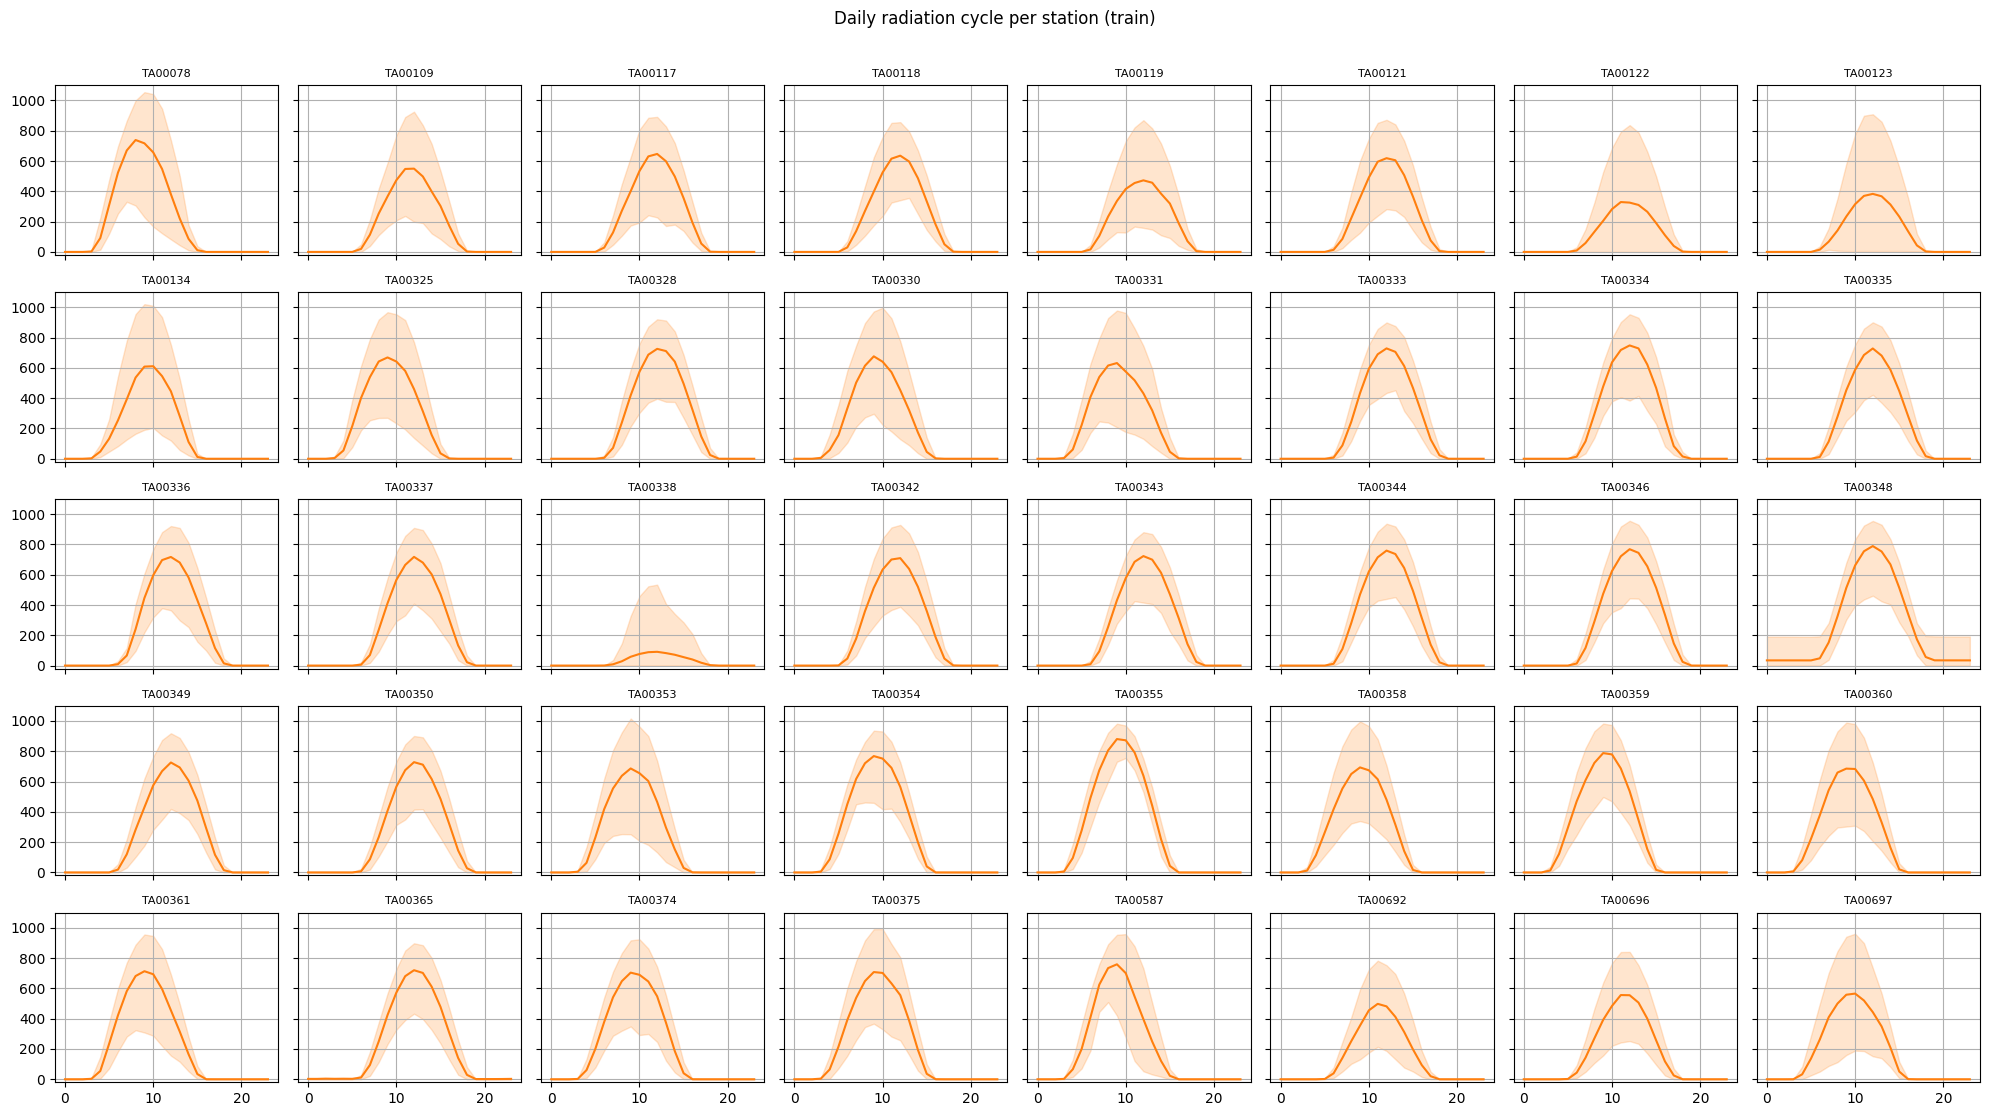

In [7]:
train = df[df["split"] == "train"].copy()
hourly = (train.groupby(["station", "hour"])[RAD]
          .agg(["mean", lambda s: s.quantile(0.1), lambda s: s.quantile(0.9)])
          .rename(columns={"<lambda_0>": "p10", "<lambda_1>": "p90"})
          .reset_index())

stations = sorted(train["station"].unique())
fig, axes = plt.subplots(5, 8, figsize=(20, 11), sharex=True, sharey=True)
for ax, s in zip(axes.ravel(), stations):
    g = hourly[hourly["station"] == s]
    ax.plot(g["hour"], g["mean"], color="tab:orange", lw=1.5)
    ax.fill_between(g["hour"], g["p10"], g["p90"], color="tab:orange", alpha=0.2)
    ax.set_title(s, fontsize=8); ax.set_ylim(-20, 1100)
fig.suptitle("Daily radiation cycle per station (train)", y=1.01)
fig.tight_layout(); plt.show()


## C. Radiation vs cos(zenith)

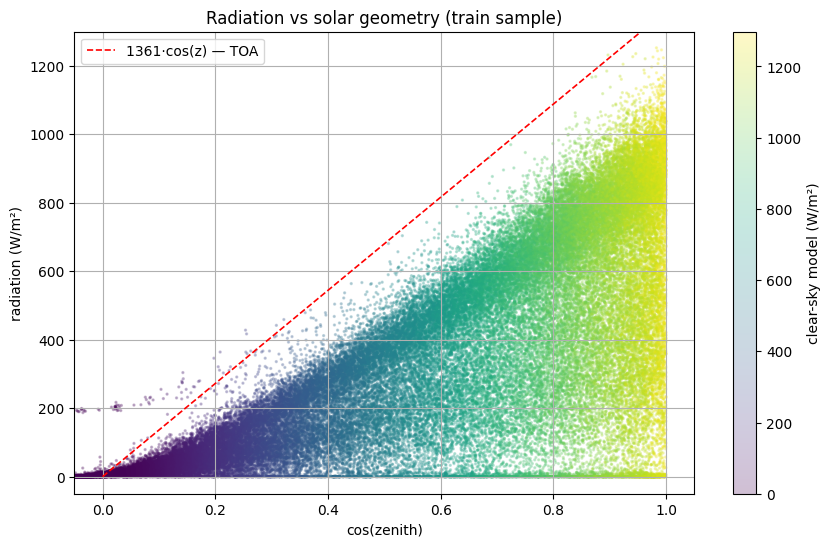

In [8]:
sample = train.sample(n=min(150_000, len(train)), random_state=0)
sample = sample[sample["ext_sol_zenith"].notna()]
cos_z = np.cos(np.radians(sample["ext_sol_zenith"]))

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(cos_z, sample[RAD], c=sample["ext_sol_clearsky"], s=2, alpha=0.25, cmap="viridis")
x = np.linspace(0, 1, 100)
ax.plot(x, 1361 * x, color="red", lw=1.2, ls="--", label="1361·cos(z) — TOA")
ax.set_xlabel("cos(zenith)"); ax.set_ylabel("radiation (W/m²)")
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-50, 1300)
plt.colorbar(sc, ax=ax, label="clear-sky model (W/m²)")
ax.legend(); ax.set_title("Radiation vs solar geometry (train sample)")
plt.show()


## D. Distribution of radiation

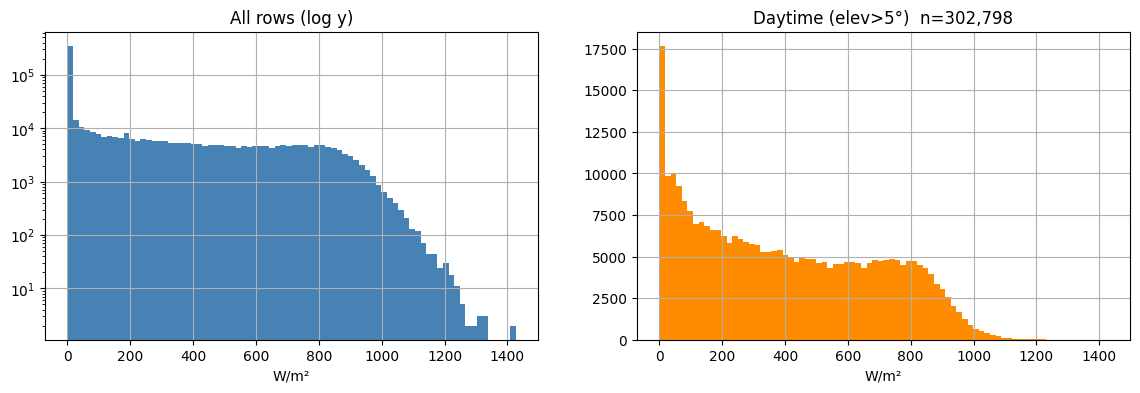

Total: 642,175, exact-zero: 322,869 (50.3%)
Night mean rad: 1.01


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(train[RAD], bins=80, color="steelblue"); axes[0].set_yscale("log")
axes[0].set_title("All rows (log y)"); axes[0].set_xlabel("W/m²")
day = train[train["ext_sol_elevation"] > 5]
axes[1].hist(day[RAD], bins=80, color="darkorange")
axes[1].set_title(f"Daytime (elev>5°)  n={len(day):,}"); axes[1].set_xlabel("W/m²")
plt.show()

print(f"Total: {len(train):,}, exact-zero: {(train[RAD]==0).sum():,} ({(train[RAD]==0).mean()*100:.1f}%)")
print(f"Night mean rad: {train.loc[train['ext_sol_elevation']<=0, RAD].mean():.2f}")


## E. Train/test coverage per station × month

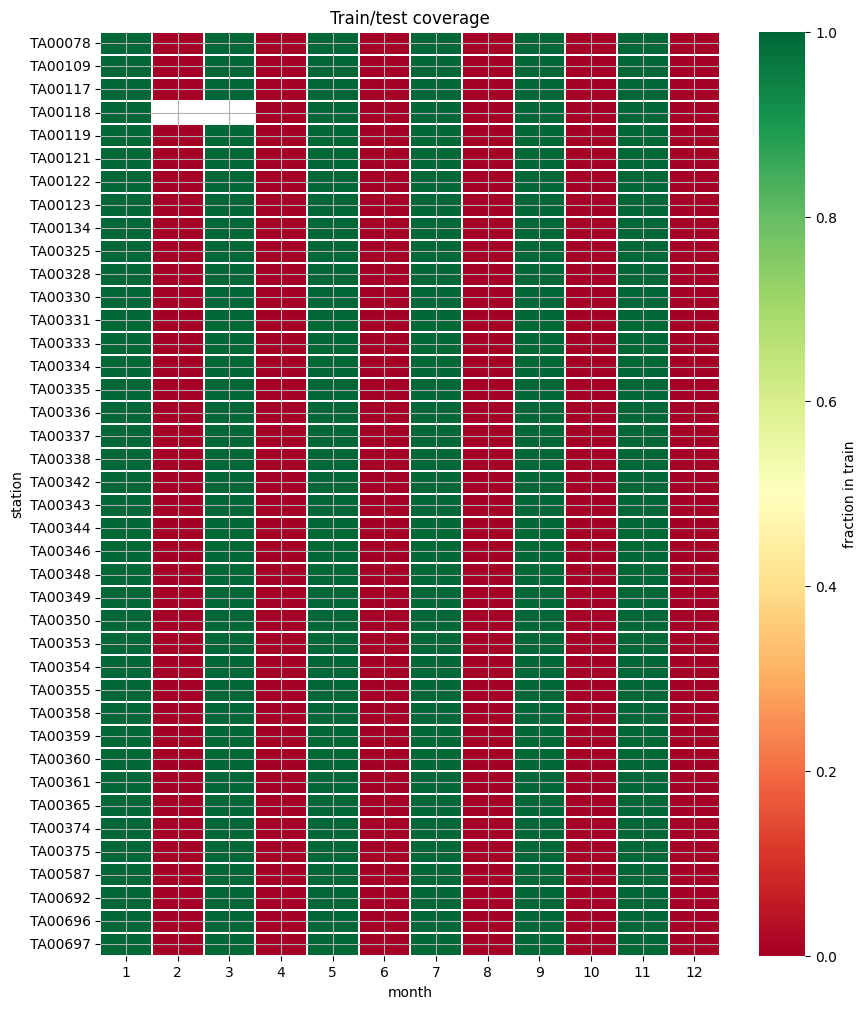

In [10]:
cov = df.groupby(["station","month","split"]).size().unstack("split", fill_value=0).reset_index()
cov["frac_train"] = cov["train"] / (cov["train"]+cov["test"]).replace(0, np.nan)
pivot = cov.pivot(index="station", columns="month", values="frac_train")
fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(pivot, cmap="RdYlGn", center=0.5, vmin=0, vmax=1, linewidths=0.2,
            cbar_kws={"label":"fraction in train"}, ax=ax)
ax.set_title("Train/test coverage")
plt.show()


## F. Weather → radiation correlations

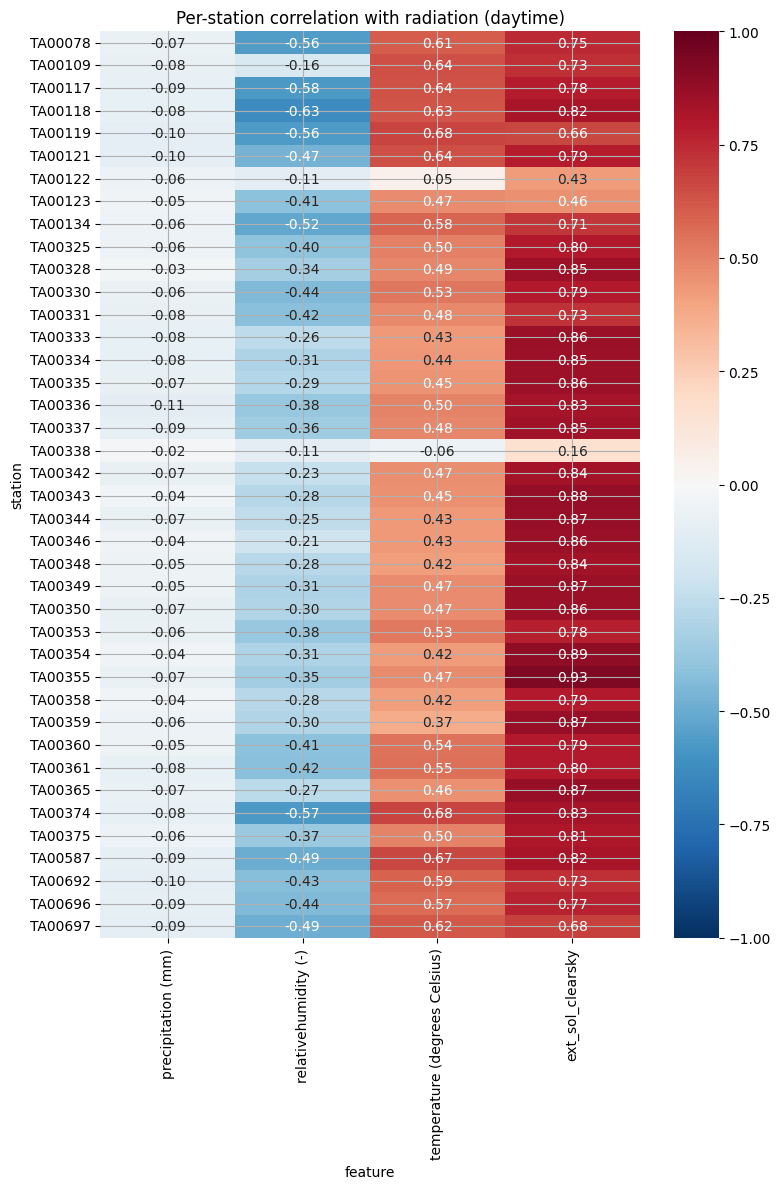

Median across stations:
feature
precipitation (mm)              -0.07
relativehumidity (-)            -0.37
temperature (degrees Celsius)    0.49
ext_sol_clearsky                 0.82


In [11]:
WEATHER = ["precipitation (mm)", "relativehumidity (-)", "temperature (degrees Celsius)", "ext_sol_clearsky"]
day = train[train["ext_sol_elevation"] > 0].copy()
rows = []
for s in sorted(day["station"].unique()):
    g = day[day["station"] == s]
    for w in WEATHER:
        rows.append({"station": s, "feature": w, "corr": g[[w, RAD]].corr().iloc[0, 1]})
heat = pd.DataFrame(rows).pivot(index="station", columns="feature", values="corr")[WEATHER]
fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(heat, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax)
ax.set_title("Per-station correlation with radiation (daytime)")
plt.tight_layout(); plt.show()
print("Median across stations:"); print(heat.median().round(2).to_string())


## G. Outlier sanity

min=0.00, max=1427.00, <0: 0, >1361: 2, >1400: 2
Night: 320,419 rows, 311,671 zero, 8,748 nonzero (mean 37.05)


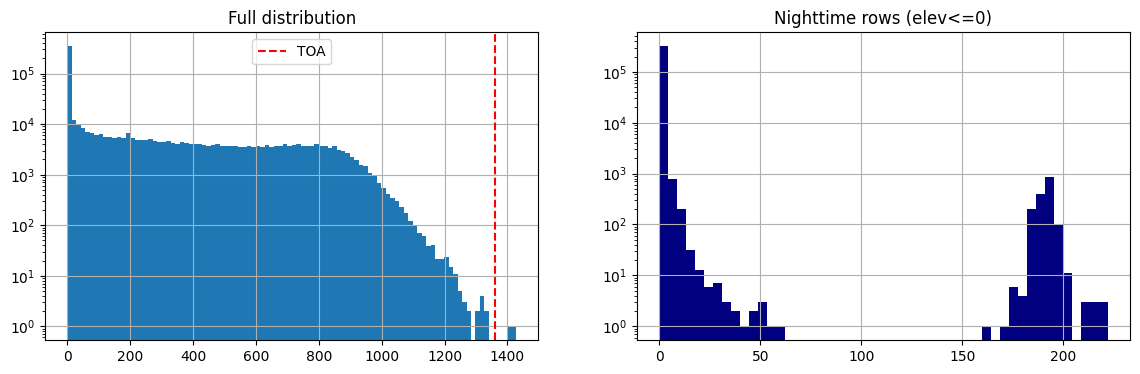

In [12]:
tr = train[RAD]
print(f"min={tr.min():.2f}, max={tr.max():.2f}, <0: {(tr<0).sum():,}, >1361: {(tr>1361).sum():,}, >1400: {(tr>1400).sum():,}")
night = train[train["ext_sol_elevation"] <= 0]
print(f"Night: {len(night):,} rows, {(night[RAD]==0).sum():,} zero, {(night[RAD]!=0).sum():,} nonzero (mean {night.loc[night[RAD]!=0, RAD].mean():.2f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(tr, bins=100); axes[0].set_yscale("log"); axes[0].axvline(1361, color="red", ls="--", label="TOA"); axes[0].legend()
axes[0].set_title("Full distribution")
axes[1].hist(night[RAD], bins=50, color="navy"); axes[1].set_yscale("log")
axes[1].set_title("Nighttime rows (elev<=0)")
plt.show()


## H. Within-year-1 drift

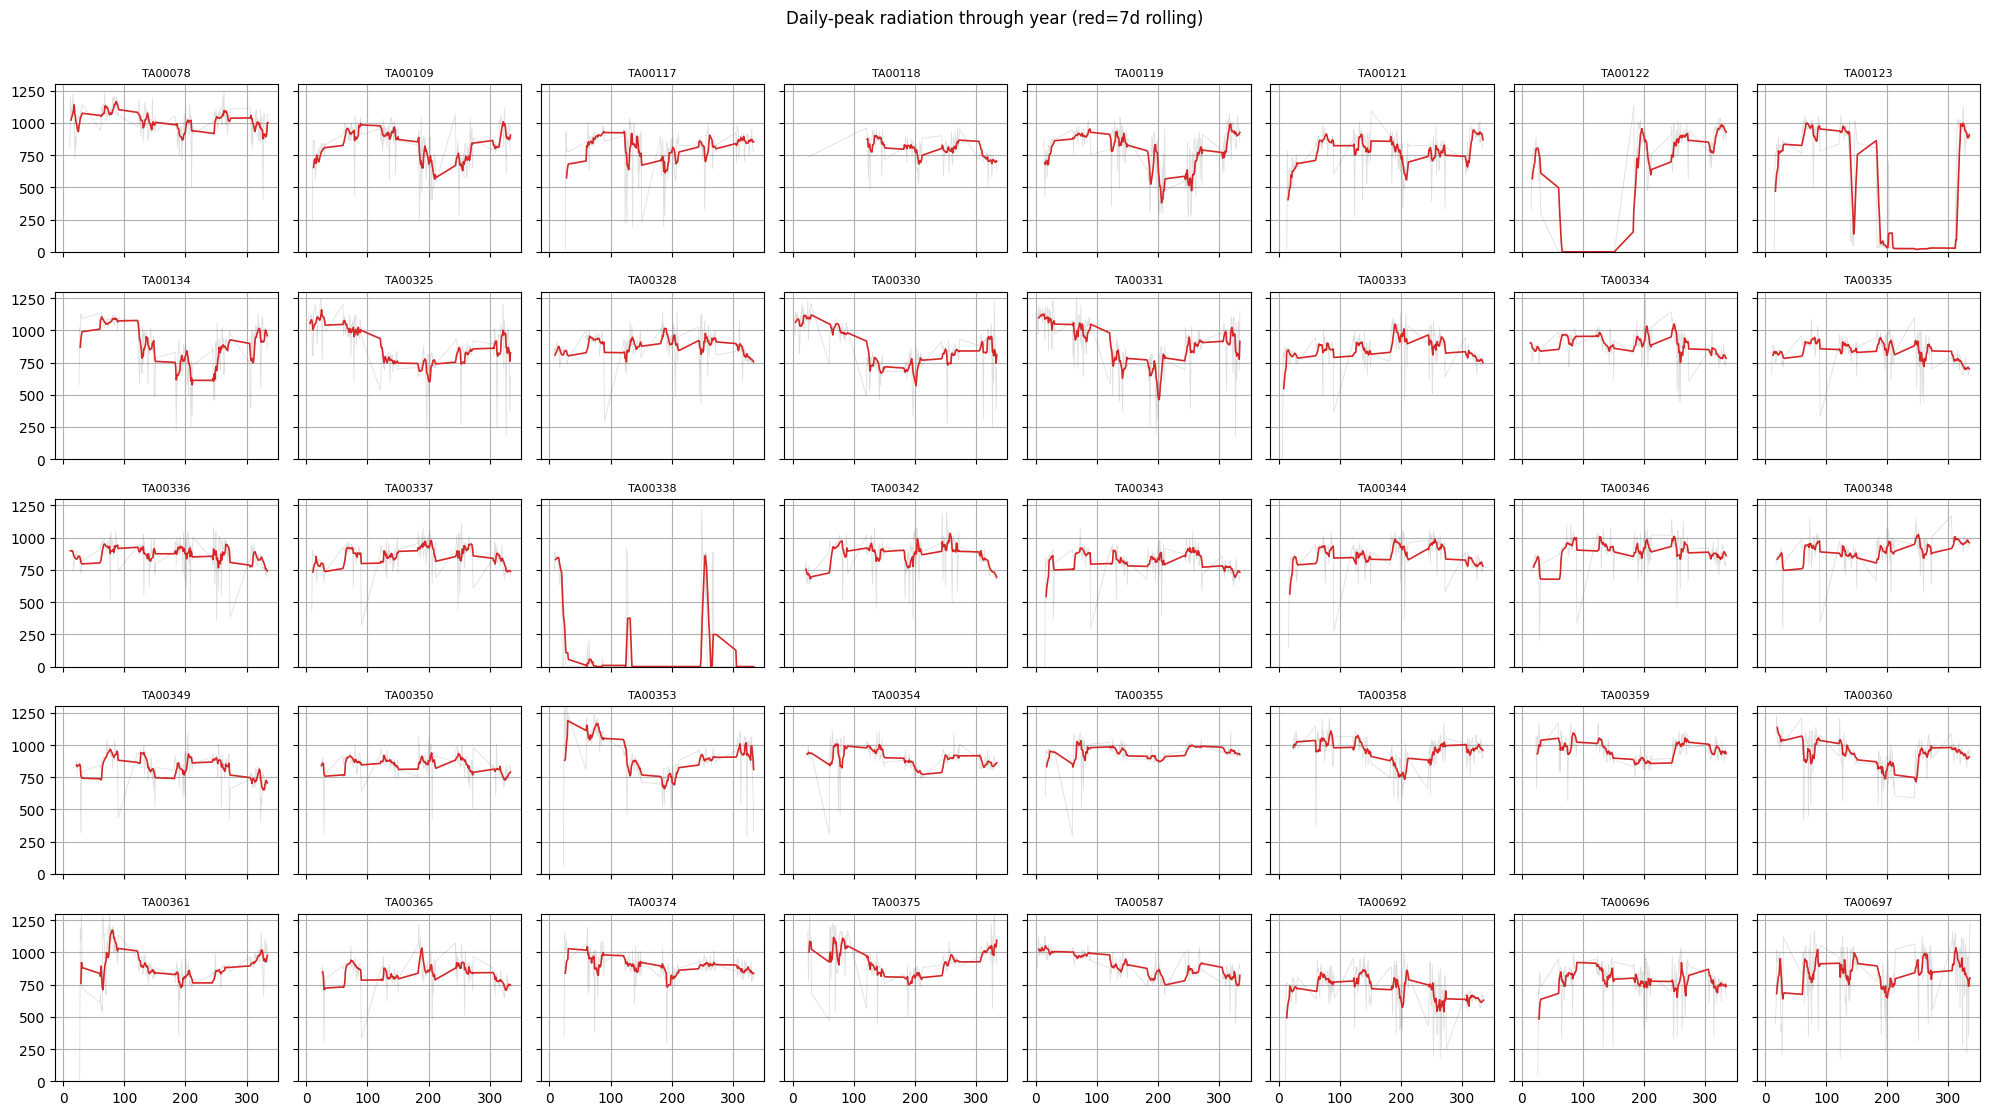

In [13]:
dmax = (train.groupby(["station", train["timestamp"].dt.date])[RAD].max()
         .reset_index().rename(columns={"timestamp":"date", RAD:"rad_max"}))
dmax["date"] = pd.to_datetime(dmax["date"]); dmax["doy"] = dmax["date"].dt.dayofyear
dmax = dmax.sort_values(["station","date"])
dmax["smooth"] = dmax.groupby("station")["rad_max"].transform(lambda s: s.rolling(7, min_periods=3).mean())

fig, axes = plt.subplots(5, 8, figsize=(20, 11), sharex=True, sharey=True)
for ax, s in zip(axes.ravel(), sorted(dmax["station"].unique())):
    g = dmax[dmax["station"]==s]
    ax.plot(g["doy"], g["rad_max"], alpha=0.25, lw=0.6, color="gray")
    ax.plot(g["doy"], g["smooth"], color="tab:red", lw=1.2)
    ax.set_title(s, fontsize=8); ax.set_ylim(0, 1300)
fig.suptitle("Daily-peak radiation through year (red=7d rolling)", y=1.01)
fig.tight_layout(); plt.show()


## I. Clearness index (KT)

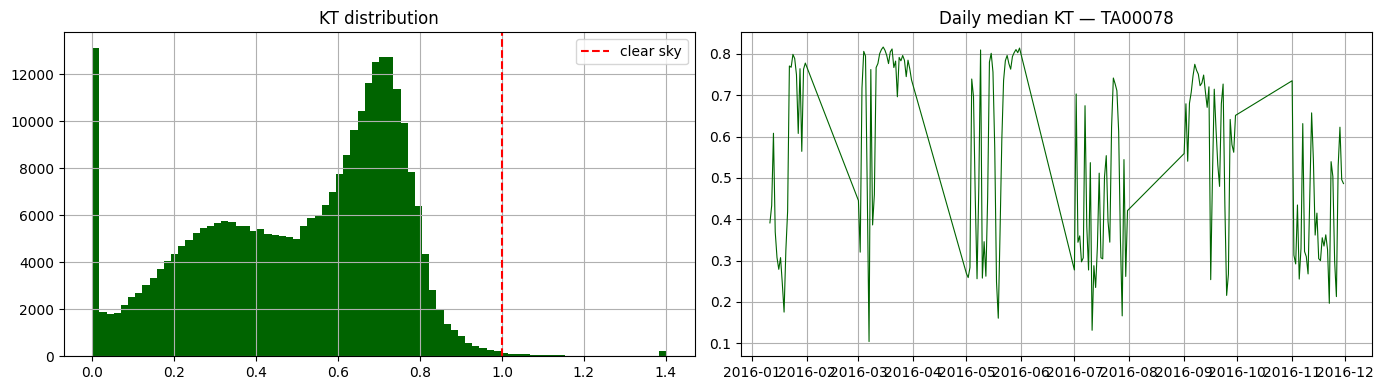

KT mean=0.50  med=0.56  p10=0.15  p90=0.77
KT > 1: 1,099 (0.4%)


In [14]:
mask = train["ext_sol_clearsky"] > 50
kt = train.loc[mask, RAD] / train.loc[mask, "ext_sol_clearsky"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(kt.clip(-0.1, 1.4), bins=80, color="darkgreen")
axes[0].axvline(1.0, color="red", ls="--", label="clear sky"); axes[0].legend()
axes[0].set_title("KT distribution")
example = sorted(train["station"].unique())[0]
g = train[(train["station"]==example) & mask].copy()
g["kt"] = g[RAD] / g["ext_sol_clearsky"]
daily_kt = g.groupby(g["timestamp"].dt.date)["kt"].median()
axes[1].plot(pd.to_datetime(daily_kt.index), daily_kt.values, lw=0.8, color="darkgreen")
axes[1].set_title(f"Daily median KT — {example}")
plt.tight_layout(); plt.show()
print(f"KT mean={kt.mean():.2f}  med={kt.median():.2f}  p10={kt.quantile(0.1):.2f}  p90={kt.quantile(0.9):.2f}")
print(f"KT > 1: {(kt>1).sum():,} ({(kt>1).mean()*100:.1f}%)")


## J. Per-station nighttime offset  (NEW)

Forum-confirmed fact: TAHMO training data is raw and many stations show
non-zero radiation at night. Before deciding whether to predict 0 globally
or a station-specific offset, measure how big each station's offset is.

Strategy implication:
- If most stations' nighttime mean ≈ 0, global `pred=0 when elev≤0` is fine.
- If a handful have a clear ≥5 W/m² floor, use a per-station lookup —
  global 0 will under-predict those.


Top 15 by nighttime mean radiation:
         n_rows  pct_nonzero  mean_rad  median_rad  p90_rad  max_rad
station                                                             
TA00348    7924        21.21     36.38         0.0    191.0    201.0
TA00365    7432         3.83      2.30         0.0      0.0    222.0
TA00331    8493         3.43      0.16         0.0      0.0     52.0
TA00325    8703         3.39      0.14         0.0      0.0     62.0
TA00330    8741         3.19      0.14         0.0      0.0     48.0
TA00359    7757         3.04      0.08         0.0      0.0     12.0
TA00349    7821         2.70      0.08         0.0      0.0     22.0
TA00350    7645         2.62      0.08         0.0      0.0     27.0
TA00346    7975         2.52      0.08         0.0      0.0     50.0
TA00334    8220         2.35      0.07         0.0      0.0     35.0
TA00333    8547         2.50      0.07         0.0      0.0     15.0
TA00374    7711         2.41      0.07         0.0      0.0     25.

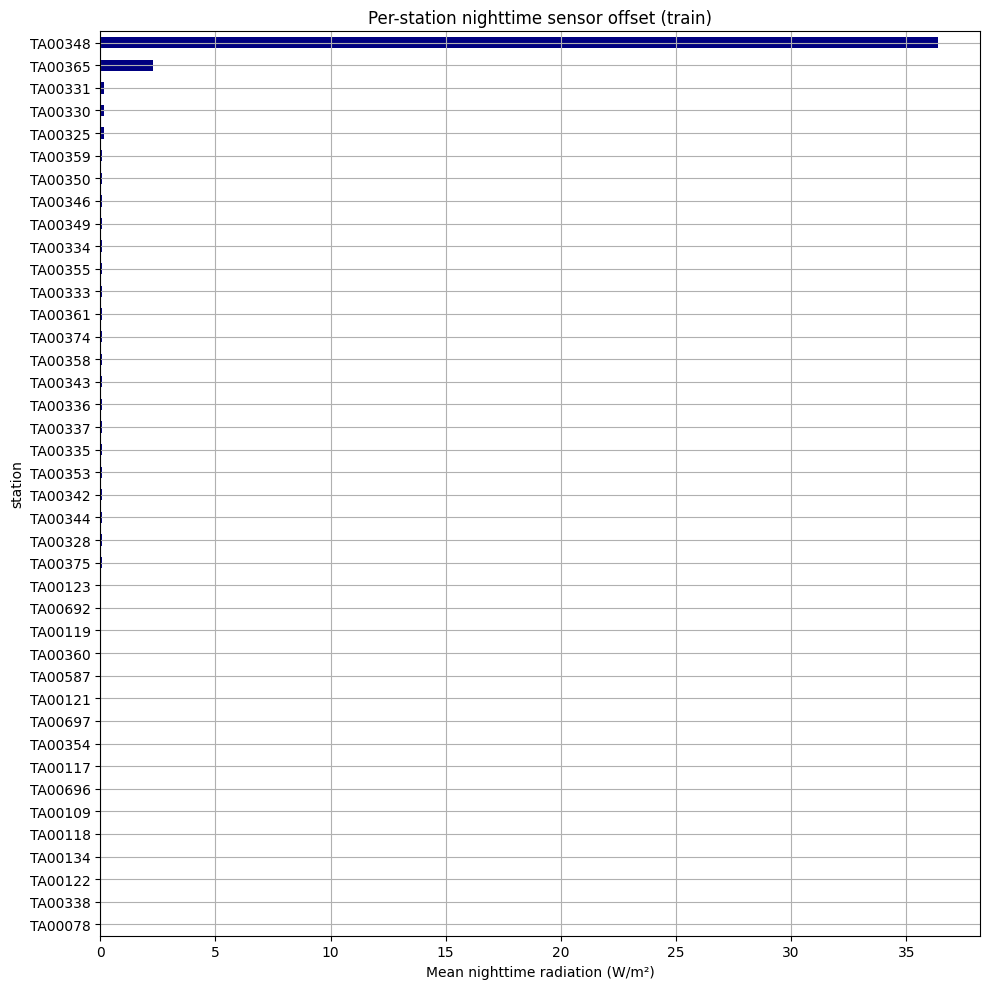

In [15]:
night = train[train["ext_sol_elevation"] <= 0].copy()
offset = (night.groupby("station")[RAD]
          .agg(n_rows="size",
               pct_nonzero=lambda s: (s > 0).mean() * 100,
               mean_rad="mean",
               median_rad="median",
               p90_rad=lambda s: s.quantile(0.9),
               max_rad="max")
          .sort_values("mean_rad", ascending=False).round(2))
print("Top 15 by nighttime mean radiation:")
print(offset.head(15).to_string())
print("\nBottom 10 (cleanest nighttime):")
print(offset.tail(10).to_string())

offset.to_csv("../data/processed/night_offset_per_station.csv")
print("\nSaved: data/processed/night_offset_per_station.csv")

fig, ax = plt.subplots(figsize=(10, 10))
offset["mean_rad"].sort_values().plot(kind="barh", ax=ax, color="navy")
ax.set_xlabel("Mean nighttime radiation (W/m²)"); ax.axvline(0, color="k", lw=0.5)
ax.set_title("Per-station nighttime sensor offset (train)")
plt.tight_layout(); plt.show()


## K. Per-station anomaly score  (NEW)

Ranks each station by total anomaly load:
- null rad fraction (defective like TA00338)
- nighttime non-zero fraction
- >1300 W/m² spikes
- daytime zero fraction (cloudy OR stuck-at-zero)

Use to flag stations needing fallback predictions.


In [16]:
g = train.groupby("station")
anomaly = pd.DataFrame({
    "n_rows":            g.size(),
    "null_rad_pct":      g[RAD].apply(lambda s: s.isna().mean() * 100),
    "night_nonzero_pct": g.apply(lambda d: ((d["ext_sol_elevation"]<=0) & (d[RAD]>0)).sum() / max(1,(d["ext_sol_elevation"]<=0).sum()) * 100),
    "rad_over_1300_pct": g[RAD].apply(lambda s: (s > 1300).mean() * 100),
    "day_zero_pct":      g.apply(lambda d: ((d["ext_sol_elevation"]>5) & (d[RAD]<1)).sum() / max(1,(d["ext_sol_elevation"]>5).sum()) * 100),
})
norm = anomaly.drop(columns=["n_rows"]).apply(lambda s: s / max(s.max(), 1e-9))
anomaly["anomaly_score"] = norm.sum(axis=1).round(3)
anomaly = anomaly.sort_values("anomaly_score", ascending=False).round(2)
print("Per-station anomaly profile (worst first):")
print(anomaly.to_string())

anomaly.to_csv("../data/processed/station_anomaly_scores.csv")
print("\nSaved: data/processed/station_anomaly_scores.csv")

if "TA00338" in anomaly.index:
    print("\n--- TA00338 (forum-flagged defective sensor) ---")
    print(anomaly.loc["TA00338"].to_string())


Per-station anomaly profile (worst first):
         n_rows  null_rad_pct  night_nonzero_pct  rad_over_1300_pct  day_zero_pct  anomaly_score
station                                                                                         
TA00375   15313           0.0               2.38               0.03          0.00           1.11
TA00338   16939           0.0               0.36               0.00         85.53           1.02
TA00348   15995           0.0              21.21               0.00          0.00           1.00
TA00361   15102           0.0               2.79               0.02          0.00           0.89
TA00353   15492           0.0               2.65               0.01          0.00           0.62
TA00122   16257           0.0               1.17               0.00         38.51           0.50
TA00334   16559           0.0               2.35               0.01          0.01           0.34
TA00365   14995           0.0               3.83               0.00          0.04   

## L. Geographic view of anomalies  (NEW)

A station-position scatter colored by anomaly score, plus a country-level
roll-up. Answers two questions:

- **Do anomalies cluster geographically?** If yes (e.g., all Mali stations
  share the same nighttime offset), pool training across the cluster — one
  shared correction beats 14 noisy per-station estimates.
- **Where does TA00338 sit?** If nearby stations have low anomaly scores,
  their model is a reasonable fallback for TA00338's 95%-null rows.


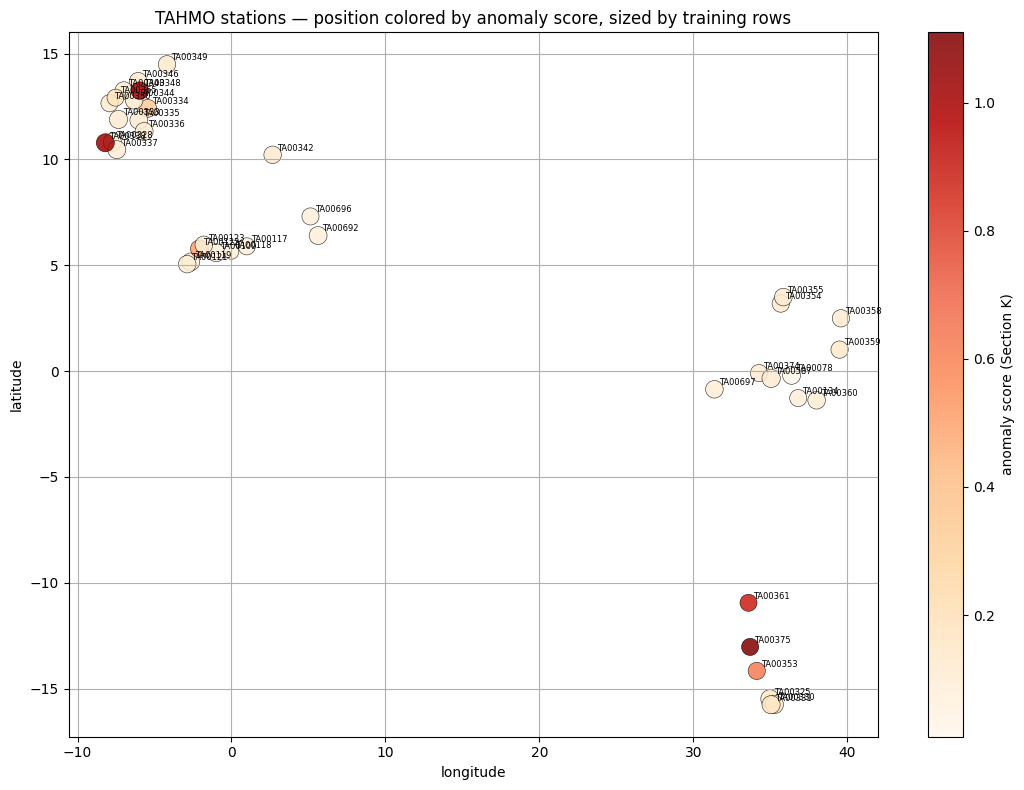

Country-level anomaly roll-up:
         n_stations  mean_anomaly  mean_null_pct  mean_night_nonzero
country                                                             
MW                6          0.52            0.0                2.97
ML               14          0.26            0.0                3.74
GH                7          0.15            0.0                1.77
BJ                1          0.12            0.0                2.42
KE                9          0.10            0.0                2.10
UG                1          0.10            0.0                2.13
NG                2          0.08            0.0                1.66


In [17]:
# Station-level metadata: lat, lon, country
station_meta = (df.groupby("station")[["latitude", "longitude", "country"]].first())

# Join anomaly profile from Section K (in memory)
geo = station_meta.join(anomaly, how="inner")

# 1. Map-style scatter, colored by anomaly_score, sized by training rows
fig, ax = plt.subplots(figsize=(11, 8))
sc = ax.scatter(geo["longitude"], geo["latitude"],
                c=geo["anomaly_score"], s=geo["n_rows"] / 100,
                cmap="OrRd", edgecolor="k", linewidth=0.4, alpha=0.85)
for sid, row in geo.iterrows():
    ax.annotate(sid, (row["longitude"], row["latitude"]),
                fontsize=6, xytext=(3, 3), textcoords="offset points")
plt.colorbar(sc, ax=ax, label="anomaly score (Section K)")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title("TAHMO stations — position colored by anomaly score, sized by training rows")
plt.tight_layout(); plt.show()

# 2. Country-level roll-up
country_summary = (geo.groupby("country")
                   .agg(n_stations=("anomaly_score", "size"),
                        mean_anomaly=("anomaly_score", "mean"),
                        mean_null_pct=("null_rad_pct", "mean"),
                        mean_night_nonzero=("night_nonzero_pct", "mean"))
                   .round(2)
                   .sort_values("mean_anomaly", ascending=False))
print("Country-level anomaly roll-up:")
print(country_summary.to_string())


## M. Radiation by installation year  (NEW)

Each station has ~1 year of data, but the *which year* differs: stations were
installed across 2016–2020. So "year" varies across stations but not within a
station. This matters because:

- Year-specific weather (e.g., 2018 vs. 2020 ENSO state) leaks into the
  station signal. Two stations 100 km apart from different install years
  may look different because of the year, not the location.
- If your training fold accidentally splits stations along year, validation
  can over/underestimate generalization.
- The dominant year is 2018 (most stations) — your model's behavior will be
  biased toward 2018 climate unless you weight or stratify.


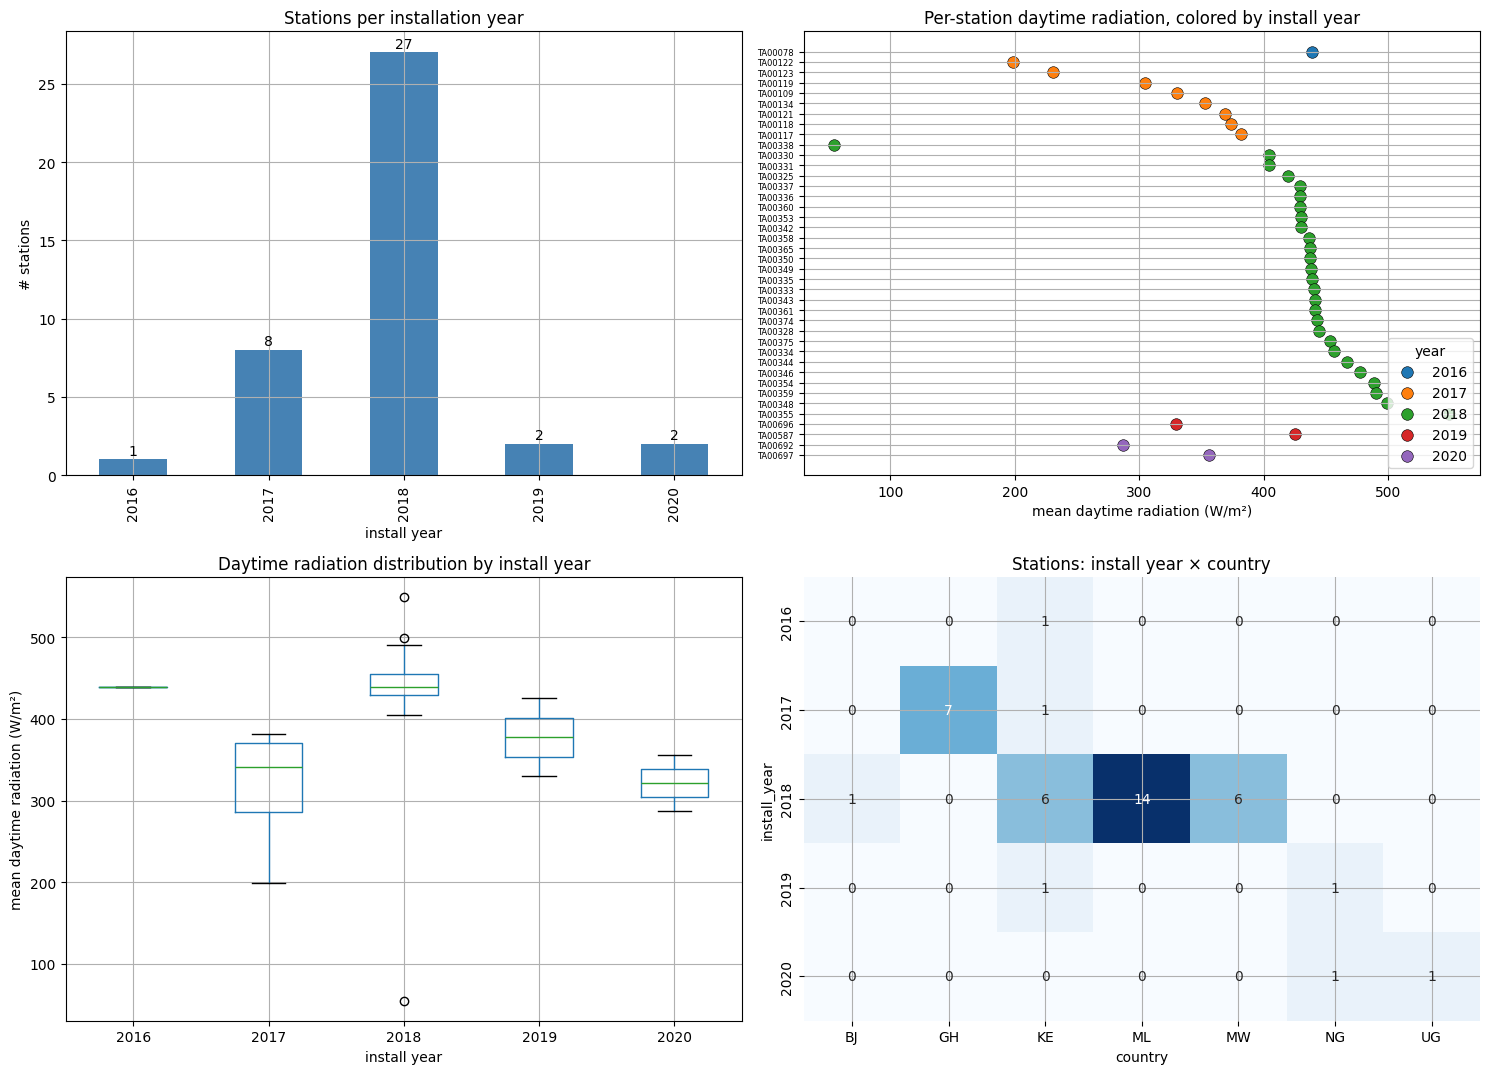


Install-year distribution: {2016: np.int64(1), 2017: np.int64(8), 2018: np.int64(27), 2019: np.int64(2), 2020: np.int64(2)}

Mean daytime radiation by install year:
              count   mean   std
install_year                    
2016              1  439.0   NaN
2017              8  317.7  68.8
2018             27  433.7  81.8
2019              2  377.6  67.8
2020              2  321.5  48.9


In [18]:
year_of = (df.groupby("station")["timestamp"]
            .min().dt.year.rename("install_year"))

# Daytime mean radiation per station
day_rad = (train[train["ext_sol_elevation"] > 5]
           .groupby("station")[RAD].mean()
           .rename("mean_daytime_rad"))

year_df = pd.concat([year_of, day_rad], axis=1).reset_index().dropna()
year_df["country"] = year_df["station"].map(df.groupby("station")["country"].first())

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# (1) Counts of stations per install year
ax = axes[0, 0]
counts = year_of.value_counts().sort_index()
counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Stations per installation year")
ax.set_xlabel("install year"); ax.set_ylabel("# stations")
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=10)

# (2) Mean daytime radiation per station, colored by year
ax = axes[0, 1]
year_palette = {y: c for y, c in zip(sorted(year_df["install_year"].unique()),
                                       sns.color_palette("tab10", n_colors=5))}
for y, sub in year_df.sort_values("mean_daytime_rad").groupby("install_year"):
    ax.scatter(sub["mean_daytime_rad"], range(len(sub)) if False else sub.index,
               c=[year_palette[y]], label=str(y), s=70, edgecolor="k", linewidth=0.4)
ax.set_yticks(range(len(year_df)))
ax.set_yticklabels(year_df.sort_values("install_year")["station"], fontsize=6)
# Order y-axis by year for legibility
order = year_df.sort_values(["install_year", "mean_daytime_rad"]).reset_index(drop=True)
ax.clear()
for y, sub in order.groupby("install_year"):
    ax.scatter(sub["mean_daytime_rad"], sub.index,
               c=[year_palette[y]], label=str(y), s=70, edgecolor="k", linewidth=0.4)
ax.set_yticks(order.index); ax.set_yticklabels(order["station"], fontsize=6)
ax.set_xlabel("mean daytime radiation (W/m²)"); ax.set_title("Per-station daytime radiation, colored by install year")
ax.legend(title="year", loc="lower right")
ax.invert_yaxis()

# (3) Boxplot: daytime radiation by install year
ax = axes[1, 0]
year_df.boxplot(column="mean_daytime_rad", by="install_year", ax=ax)
ax.set_title("Daytime radiation distribution by install year"); ax.set_xlabel("install year")
ax.set_ylabel("mean daytime radiation (W/m²)")
plt.suptitle("")

# (4) Year × country crosstab
ax = axes[1, 1]
ct = pd.crosstab(year_df["install_year"], year_df["country"])
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Stations: install year × country")

plt.tight_layout(); plt.show()

print(f"\nInstall-year distribution: {dict(counts)}")
print(f"\nMean daytime radiation by install year:")
print(year_df.groupby("install_year")["mean_daytime_rad"].agg(["count","mean","std"]).round(1).to_string())


## N. External features: which ones correlate with radiation?  (NEW)

Now that the satellite pipeline is mostly done (Solar, SARAH, ERA5, CAMS —
TROPOMI still extracting), it's worth quantifying **how much each new feature
buys** before modelling. Three questions answered below:

1. Which `ext_*` columns have the strongest correlation with target radiation?
2. **`ext_era5_ssrd` is ECMWF's own modelled radiation.** How good is it as a
   prediction on its own — what would |MBE| + RMSE be if I just submitted it?
3. Which features look redundant (highly correlated with each other)?


In [19]:
# Load the enhanced train file (with all available external features)
ENH_PATH = "../data/processed/Train_enhanced.csv"
df_enh = pd.read_csv(ENH_PATH, parse_dates=["timestamp"])

ext_cols = [c for c in df_enh.columns if c.startswith("ext_")]
print(f"Train_enhanced shape: {df_enh.shape}")
print(f"External features available ({len(ext_cols)}):")
for c in ext_cols:
    pct = df_enh[c].notna().mean() * 100
    print(f"  {c:30s}  coverage {pct:5.1f}%")


Train_enhanced shape: (642175, 34)
External features available (21):
  ext_sol_zenith                  coverage 100.0%
  ext_sol_azimuth                 coverage 100.0%
  ext_sol_elevation               coverage 100.0%
  ext_sol_hour_angle              coverage 100.0%
  ext_sol_declination             coverage 100.0%
  ext_sol_eqtime                  coverage 100.0%
  ext_sol_earth_sun_dist          coverage 100.0%
  ext_sol_clearsky                coverage 100.0%
  ext_sol_daylight                coverage 100.0%
  ext_sol_day_length              coverage 100.0%
  ext_lsa_dni                     coverage 100.0%
  ext_lsa_sid                     coverage 100.0%
  ext_lsa_sis                     coverage 100.0%
  ext_era5_ssrd                   coverage 100.0%
  ext_era5_tcc                    coverage 100.0%
  ext_era5_tcwv                   coverage 100.0%
  ext_era5_blh                    coverage 100.0%
  ext_era5_sp                     coverage 100.0%
  ext_cams_aod550              

### N.1 Correlation of each ext_* feature with radiation

Daytime only (`ext_sol_elevation > 5°`). CAMS is 3-hourly so we forward-fill
within each station before computing — otherwise its correlation is dominated
by missing rows.


Correlation of ext_* features with radiation (daytime):

                               r
ext_sol_clearsky        0.718007
ext_era5_ssrd           0.711015
ext_sol_zenith         -0.701726
ext_sol_elevation       0.701726
ext_era5_blh            0.353250
ext_era5_tcc           -0.206290
ext_era5_tcwv          -0.197099
ext_lsa_dni             0.195326
ext_lsa_sid             0.194644
ext_lsa_sis             0.183142
ext_cams_aod550        -0.127223
ext_cams_bcaod550      -0.093167
ext_sol_earth_sun_dist  0.090845
ext_sol_declination    -0.075214
ext_era5_sp            -0.055347
ext_sol_azimuth        -0.022334
ext_sol_hour_angle      0.021864
ext_cams_duaod550       0.021818
ext_sol_eqtime         -0.016601
ext_sol_day_length     -0.009141
ext_sol_daylight             NaN


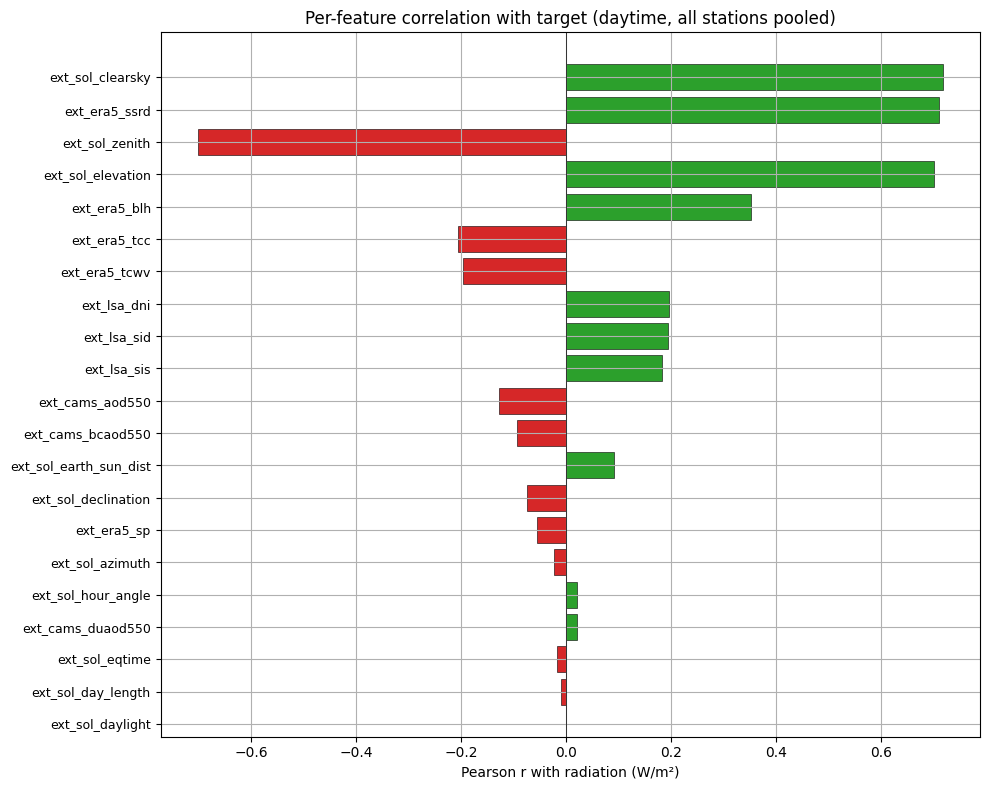

In [20]:
day_enh = df_enh[df_enh["ext_sol_elevation"] > 5].copy()

# Forward-fill CAMS within station so the 3-hourly cadence doesn't bias r
for col in ["ext_cams_aod550", "ext_cams_duaod550", "ext_cams_bcaod550"]:
    day_enh[col] = day_enh.groupby("station")[col].ffill().bfill()

corrs = day_enh[ext_cols + [RAD]].corr()[RAD].drop(RAD).sort_values(key=abs, ascending=False)
print("Correlation of ext_* features with radiation (daytime):\n")
print(corrs.to_frame("r").to_string())

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["tab:green" if v > 0 else "tab:red" for v in corrs.values]
ax.barh(range(len(corrs)), corrs.values, color=colors, edgecolor="k", linewidth=0.4)
ax.set_yticks(range(len(corrs))); ax.set_yticklabels(corrs.index, fontsize=9)
ax.invert_yaxis(); ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("Pearson r with radiation (W/m²)")
ax.set_title("Per-feature correlation with target (daytime, all stations pooled)")
plt.tight_layout(); plt.show()


### N.2 ERA5 SSRD as a free baseline

`ext_era5_ssrd` is ECMWF's *modelled* surface solar radiation at the same
location/time. If correlation is very high, it's already a near-submittable
prediction.

Compute the "what if I submitted ERA5 ssrd directly?" score on training data
(only fair on training, since test radiation is hidden). This is a free
strawman every modelling improvement has to beat.


ERA5 SSRD vs observed radiation (daytime, train only):
  |MBE|:     75.94 W/m²
  RMSE:     231.10 W/m²
  Score:    153.52  (0.5·|MBE| + 0.5·RMSE)
  n:      302,798 rows  (40 stations)

Per-station SSRD-as-prediction score (worst stations first):
           mbe   rmse  score       n
station                             
TA00338  428.4  530.8  479.6  7994.0
TA00122  176.9  341.3  259.1  7674.0
TA00123  155.9  308.9  232.4  7636.0
TA00134  126.6  240.9  183.8  7124.0
TA00587   96.2  242.8  169.5  8215.0
TA00109   86.6  229.8  158.2  7884.0
TA00692   95.9  219.2  157.5  7832.0
TA00078   57.1  255.7  156.4  7817.0
TA00349  101.7  206.8  154.3  7541.0
TA00697   70.8  232.0  151.4  7589.0


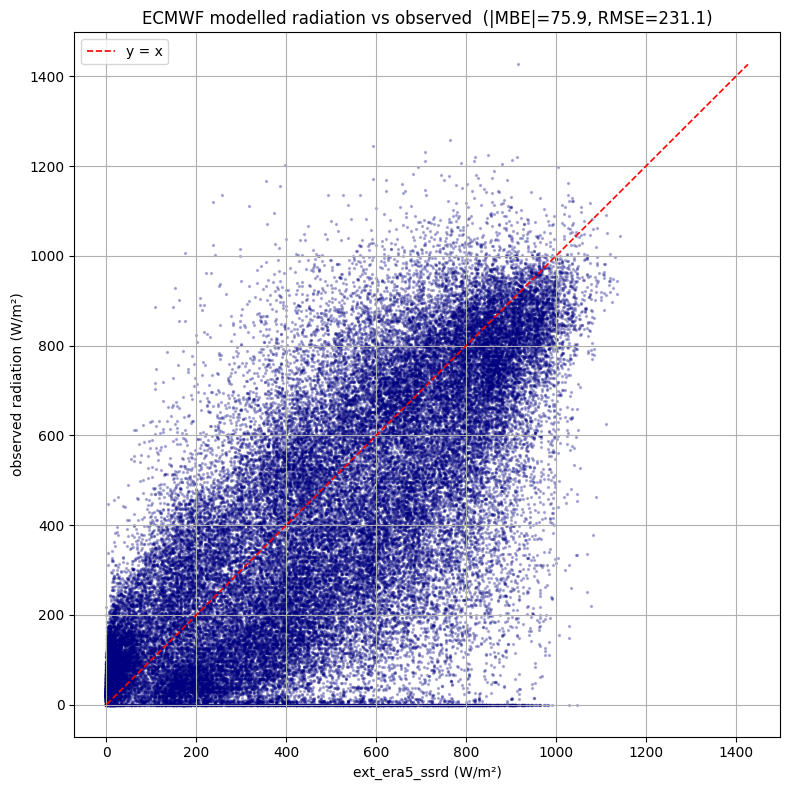

In [21]:
# Align daytime where ssrd is available
mask = day_enh["ext_era5_ssrd"].notna()
y_true = day_enh.loc[mask, RAD].values
y_pred = day_enh.loc[mask, "ext_era5_ssrd"].values

# Apply the leaderboard composite
mbe  = abs(float(np.mean(y_pred - y_true)))
rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
score = 0.5 * mbe + 0.5 * rmse

print(f"ERA5 SSRD vs observed radiation (daytime, train only):")
print(f"  |MBE|:  {mbe:8.2f} W/m²")
print(f"  RMSE:   {rmse:8.2f} W/m²")
print(f"  Score:  {score:8.2f}  (0.5·|MBE| + 0.5·RMSE)")
print(f"  n:      {len(y_true):,} rows  ({day_enh['station'].nunique()} stations)")

# Per-station strawman score
per_station = (day_enh.dropna(subset=[RAD, "ext_era5_ssrd"])
               .groupby("station")
               .apply(lambda g: pd.Series({
                   "mbe":  abs((g["ext_era5_ssrd"] - g[RAD]).mean()),
                   "rmse": np.sqrt(((g["ext_era5_ssrd"] - g[RAD])**2).mean()),
                   "score": 0.5 * abs((g["ext_era5_ssrd"] - g[RAD]).mean())
                          + 0.5 * np.sqrt(((g["ext_era5_ssrd"] - g[RAD])**2).mean()),
                   "n":    len(g),
               }))
               .round(1)
               .sort_values("score", ascending=False))
print("\nPer-station SSRD-as-prediction score (worst stations first):")
print(per_station.head(10).to_string())

# Scatter
sample = day_enh.sample(n=min(60_000, len(day_enh)), random_state=0).dropna(subset=["ext_era5_ssrd"])
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(sample["ext_era5_ssrd"], sample[RAD], s=2, alpha=0.25, c="navy")
lim = max(sample["ext_era5_ssrd"].max(), sample[RAD].max())
ax.plot([0, lim], [0, lim], color="red", lw=1.2, ls="--", label="y = x")
ax.set_xlabel("ext_era5_ssrd (W/m²)"); ax.set_ylabel("observed radiation (W/m²)")
ax.set_title(f"ECMWF modelled radiation vs observed  (|MBE|={mbe:.1f}, RMSE={rmse:.1f})")
ax.legend(); plt.tight_layout(); plt.show()


### N.3 Feature redundancy

Some features carry overlapping information. The heatmap below shows pairwise
correlation among the strongest predictors — clusters of high correlation
mean we can probably drop one of each pair without hurting the model.


Showing features with |r|>0.10 with target (11 cols):
['ext_sol_clearsky', 'ext_era5_ssrd', 'ext_sol_zenith', 'ext_sol_elevation', 'ext_era5_blh', 'ext_era5_tcc', 'ext_era5_tcwv', 'ext_lsa_dni', 'ext_lsa_sid', 'ext_lsa_sis', 'ext_cams_aod550']


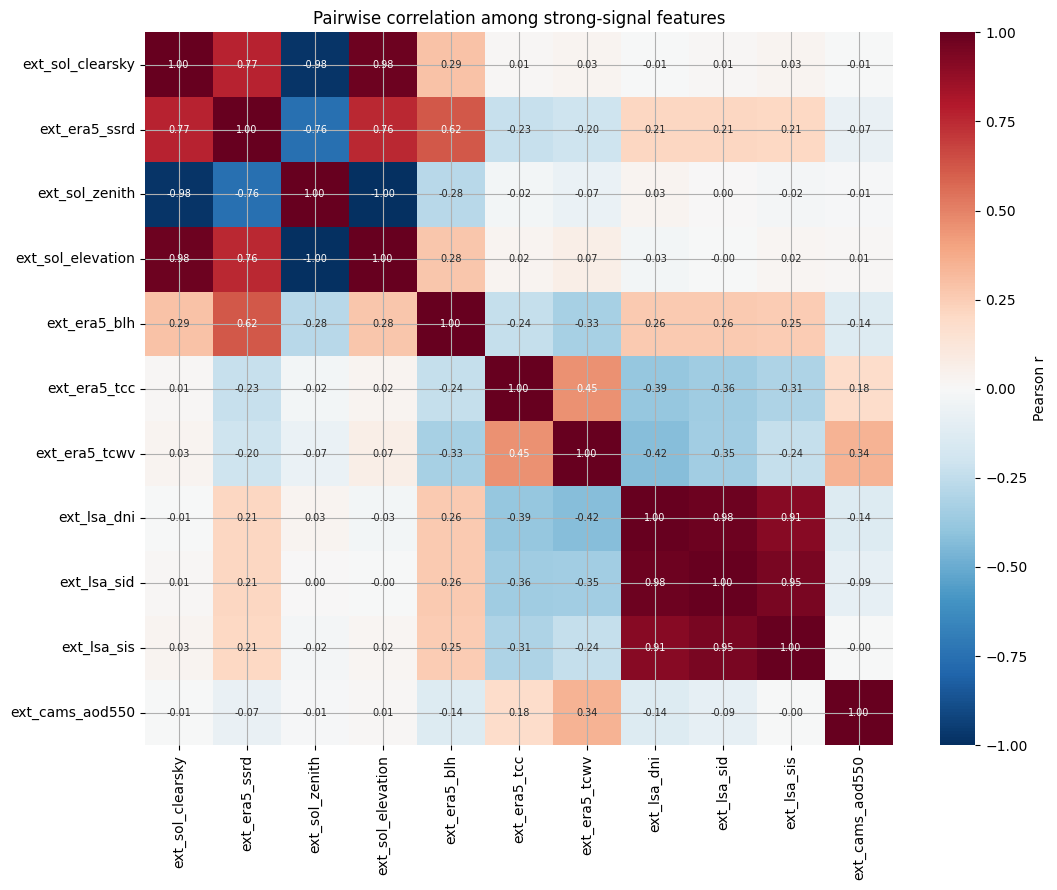


Obvious redundancy candidates:
  - ext_sol_zenith ↔ ext_sol_elevation (one is 90 - the other)
  - ext_sol_clearsky ↔ ext_sol_elevation (geometry-driven)
  - ext_lsa_sis ↔ ext_era5_ssrd (both estimate surface radiation)


In [22]:
# Use only the strongest features (|r| > 0.1 with target) for a clean heatmap
top_features = corrs[corrs.abs() > 0.10].index.tolist()
print(f"Showing features with |r|>0.10 with target ({len(top_features)} cols):")
print(top_features)

cross = day_enh[top_features].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cross, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7}, cbar_kws={"label": "Pearson r"})
ax.set_title("Pairwise correlation among strong-signal features")
plt.tight_layout(); plt.show()

print("\nObvious redundancy candidates:")
print("  - ext_sol_zenith ↔ ext_sol_elevation (one is 90 - the other)")
print("  - ext_sol_clearsky ↔ ext_sol_elevation (geometry-driven)")
print("  - ext_lsa_sis ↔ ext_era5_ssrd (both estimate surface radiation)")


## Take-aways

1. **Forum strategy**: TAHMO training data is raw (no preprocessing) and
   cleaning empirically hurts LB. Build a "mimic-the-sensor" model first;
   keep a "physical" cleanup version on the side as a hedge.
2. **`ext_era5_ssrd` is a near-zero-effort baseline.** Section N quantifies
   how good it already is. Every modelling improvement should beat it.
3. Stations dominated by anomalies (Section K) need fallback predictions —
   TA00338 especially. Use Section L geography for a fallback neighbour.
4. Year of install confounds station effects (Section M).
5. KT (Section I) cleaner than raw radiation → model KT for daytime,
   per-station offset (Section J) at night.
6. Drop redundant features after Section N.3 — `ext_sol_zenith` vs
   `ext_sol_elevation`, `ext_lsa_sis` vs `ext_era5_ssrd`, etc.
7. CV must mimic test layout: leave-one-(even-month)-out per station,
   using only training months.
